# Problem

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import random
import torch
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors

# This starts from the current working directory
# and goes up until it finds the 'fogas_torch' folder or '.git'
def find_root(current_path, marker="fogas_torch"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
print(f"Project root found at: {PROJECT_ROOT}")

# Add project root to sys.path so we can import local packages
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
# Now define the dataset path
DATASET_PATH = PROJECT_ROOT / "datasets" / "50grid.csv"
DATASET_PATH1 = PROJECT_ROOT / "datasets" / "100grid.csv"
print(f"Loading dataset from: {DATASET_PATH}")

from fogas_torch import PolicySolver, EnvDataCollector
from fogas_torch.algorithm import (
    FOGASSolverVectorized,
    FOGASOracleSolverVectorized,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from fogas.dataset_collection.dataset_analyzer import DatasetAnalyzer
from fogas_torch.fqi.fqi_solver import FQISolver
from fogas_torch.fqi.fqi_evaluator import FQIEvaluator

seed = 42
np.random.seed(seed) # Add this
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root found at: /shared/home/mauro.diaz/work/FOGAS
Loading dataset from: /shared/home/mauro.diaz/work/FOGAS/datasets/50grid.csv
Using device: cuda


# Problem

In [2]:
def create_fogas_grid(size):
    grid = np.full((size, size), '.')
    
    # Define Start and Goal
    grid[0, 0] = 'S'
    grid[size-1, size-1] = 'G'
    
    # 1. Create a Central Bottleneck (The "Great Wall")
    # Row size//2, leaving a gap of 20% at the end
    gap_limit = int(size * 0.8)
    grid[size//2, :gap_limit] = '#'
    
    # 2. Create Pit Fields (P)
    # Placing pits in clusters to test feature-based avoidance
    # Cluster 1: Early stage
    for i in range(int(size*0.1), int(size*0.3)):
        if i % 4 == 0:
            grid[i, int(size*0.4)] = 'P'
            
    # Cluster 2: After the wall bottleneck
    for i in range(int(size*0.6), int(size*0.8)):
        if i % 5 == 0:
            grid[i, int(size*0.7)] = 'P'

    # 3. Random Pillars (Scattered Walls)
    # 5% density of random walls to test local feature mapping
    for _ in range(int(size**2 * 0.05)):
        r, c = np.random.randint(0, size, 2)
        if grid[r, c] == '.':
            grid[r, c] = '#'
            
    return grid

def plot_fogas_grid(grid_data):
    """
    Visualizes large grids (50x50, 100x100) for RL analysis.
    """
    size = grid_data.shape[0]
    
    # Mapping characters to numeric values for plotting
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    # Define a high-contrast color palette
    # Empty (White), Wall (Black), Pit (Red), Start (Blue), Goal (Green)
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    # Set plot size to fit comfortably in a notebook
    plt.figure(figsize=(10, 10))
    plt.imshow(numeric_grid, cmap=cmap)
    
    # Grid lines to help distinguish cells in 50x50
    if size <= 50:
        plt.grid(which='both', color='grey', linestyle='-', linewidth=0.5, alpha=0.3)
        plt.xticks(np.arange(-0.5, size, 5), [])
        plt.yticks(np.arange(-0.5, size, 5), [])
    
    plt.title(f"FOGAS Environment: {size}x{size} Grid", fontsize=15)
    
    # Legend construction
    patches = [
        plt.plot([],[], marker="s", ms=10, ls="", color=colors[i], 
                 label=list(mapping.keys())[i])[0]  for i in range(len(colors))
    ]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    plt.show()

def scale_grid(small_grid, factor=2):
    """
    Takes a 50x50 grid and turns it into a 100x100 grid 
    by doubling every pixel (cell), making walls and pits twice as thick.
    """
    # Use numpy's repeat to double rows and columns
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)
    
    # After scaling, we must ensure there is only ONE Start and ONE Goal
    # (Otherwise you'd have a 2x2 block of 'S' and 'G')
    large_grid[large_grid == 'S'] = '.'
    large_grid[large_grid == 'G'] = '.'
    
    large_grid[0, 0] = 'S'
    large_grid[-1, -1] = 'G'
    
    return large_grid

def plot_agent_paths(grid_data, paths, title_suffix=""):
    """
    Overlays agent trajectories on the FOGAS grid.
    'paths' should be a list of lists, e.g., [[(0,0), (0,1)...], [(0,0), (1,0)...]]
    """
    size = grid_data.shape[0]
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)
    
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(numeric_grid, cmap=cmap)
    
    # Plot each path with a distinct style
    line_styles = ['-', '--', ':']
    path_colors = ['magenta', 'cyan', 'yellow']
    
    for i, path in enumerate(paths):
        if not path: continue
        rows, cols = zip(*path)
        plt.plot(cols, rows, label=f'Agent Path {i+1}', 
                 color=path_colors[i % 3], linestyle=line_styles[i % 3], 
                 linewidth=2, marker='o', markersize=3, alpha=0.8)

    plt.title(f"FOGAS Path Analysis: {size}x{size} {title_suffix}", fontsize=15)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    if size <= 50:
        plt.grid(which='both', color='grey', linestyle='-', linewidth=0.5, alpha=0.2)
        
    plt.tight_layout()
    plt.show()

def compute_optimal_path(mdp, mdp_data, size, max_steps=1000):
    """
    Computes the optimal path from start to goal by following mdp.pi_star 
    and looking up the resulting state in the transition matrix mdp.P.
    """
    current_state = mdp_data["start"]
    goal_state = mdp_data["goal"]
    pits = mdp_data["pits"]
    path = []
    
    for _ in range(max_steps):
        # Convert 1D state index back to 2D (row, col) coordinates
        r, c = divmod(current_state, size)
        path.append((r, c))
        
        # Stop condition: Reached the goal or fell into a pit
        if current_state == goal_state or current_state in pits:
            break
            
        # Extract the optimal action index from the pi_star vector at the current state
        best_a = torch.argmax(mdp.pi_star[current_state]).item()
        
        # Find the next state from the MDP transition matrix P
        # P has shape (N*A, N). The row index is: state * total_actions + action
        next_state = torch.argmax(mdp.P[current_state * mdp.A + best_a]).item()
        
        # Failsafe to prevent getting stuck in a loop against a wall
        if next_state == current_state:
            break
            
        current_state = next_state
        
    return path


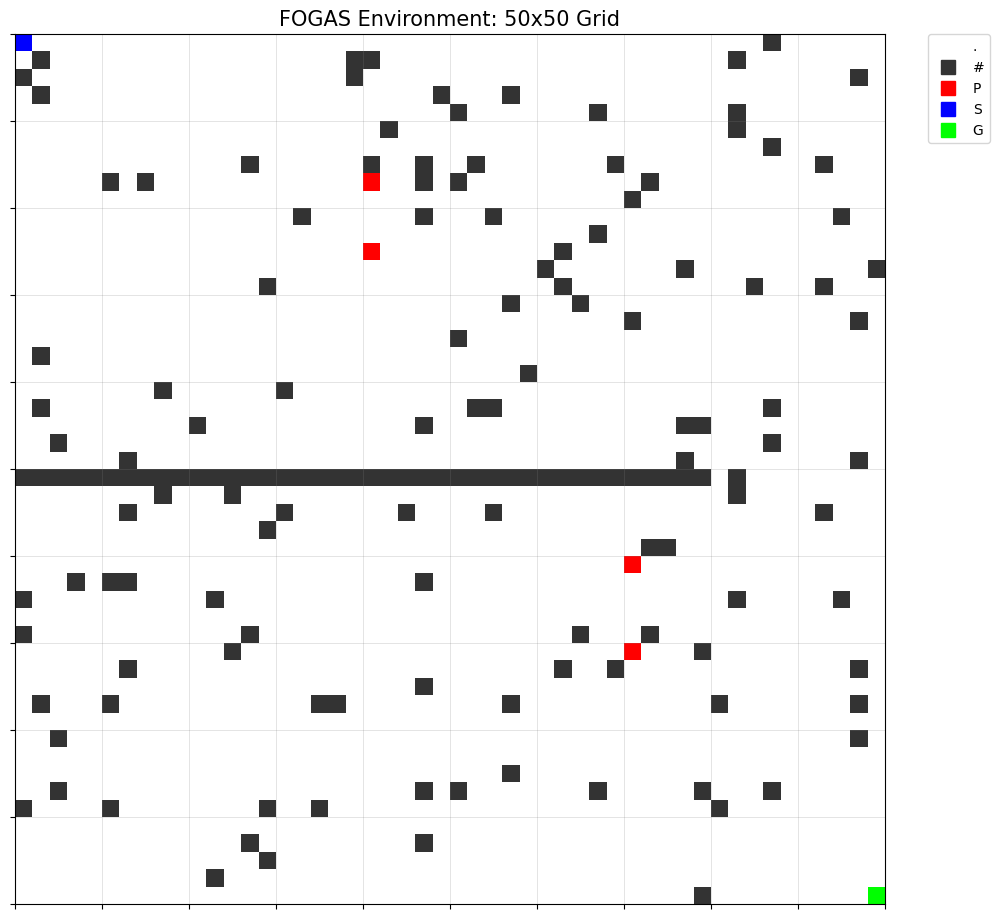

In [18]:
grid_50 = create_fogas_grid(50)
plot_fogas_grid(grid_50)


# Linear MDP

In [ ]:
def generate_mdp_regular_grid(grid_data, centers_per_side=10, gamma=0.99):
    size = grid_data.shape[0]
    N = size * size
    A = 4
    
    walls = set(np.where(grid_data.flatten() == '#')[0])
    pits = set(np.where(grid_data.flatten() == 'P')[0])
    goal = np.where(grid_data.flatten() == 'G')[0][0]
    start_node = np.where(grid_data.flatten() == 'S')[0][0]

    # --- Regular Grid Center Generation ---
    # Creates a meshgrid in normalized [0, 1] space
    ticks = np.linspace(0.0, 1.0, centers_per_side)
    c_x, c_y = np.meshgrid(ticks, ticks)
    centers = torch.tensor(np.column_stack([c_x.ravel(), c_y.ravel()]), dtype=torch.float64)
    
    def reward_fn(x, a):
        x_int = int(x)
        if x_int == goal: return 10.0
        if x_int in pits: return -10.0
        return -0.01

    P = torch.zeros((N * A, N), dtype=torch.float64)
    for x in range(N):
        for a in range(A):
            if x in pits or x == goal:
                P[x * A + a, x] = 1.0
                continue
            r, c = divmod(x, size)
            if a == 0: r_n, c_n = max(0, r-1), c
            elif a == 1: r_n, c_n = min(size-1, r+1), c
            elif a == 2: r_n, c_n = r, max(0, c-1)
            elif a == 3: r_n, c_n = r, min(size-1, c+1)
            next_s = r_n * size + c_n
            if next_s in walls: next_s = x
            P[x * A + a, next_s] = 1.0

    return {
        "centers": centers, "walls": walls, "pits": pits, 
        "goal": goal, "start": start_node, "reward_fn": reward_fn, 
        "P": P, "N": N, "A": A, "gamma": gamma
    }

def get_phi_state_func(centers, sigma, size, pits, goal):
    """Returns a scale-invariant phi_state function."""
    def phi_state(x):
        # Normalize coordinates based on the current grid size
        r, c = divmod(int(x), size)
        coords = torch.tensor([r / (size - 1), c / (size - 1)], dtype=torch.float64)
        
        # Calculate RBF activations
        dist_sq = torch.sum((coords - centers)**2, dim=1)
        rbf = torch.exp(-dist_sq / (2 * sigma**2))
        
        # Indicator features as per FOGAS standard practice
        is_pit = 1.0 if int(x) in pits else 0.0
        is_goal = 1.0 if int(x) == goal else 0.0
        indicators = torch.tensor([is_pit, is_goal], dtype=torch.float64)
        
        # Feature vector includes RBFs, Bias (1.0), and Indicators
        return torch.cat([rbf, torch.ones(1, dtype=torch.float64), indicators])
    return phi_state

def calculate_local_sigma(centers, k=2):
    """Computes sigma based on k-nearest neighbors for spatial precision."""
    dist_matrix = torch.cdist(centers, centers, p=2)
    topk_dists, _ = torch.topk(dist_matrix, k + 1, largest=False, dim=1)
    return torch.mean(topk_dists[:, 1])

def plot_grid_with_centers(grid_data, centers):
    size = grid_data.shape[0]
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)
    
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(numeric_grid, cmap=cmap)
    
    # Overlay Centers (Scaled back from [0,1] to [0, size-1])
    centers_scaled = centers.numpy() * (size - 1)
    plt.scatter(centers_scaled[:, 1], centers_scaled[:, 0], 
                c='blue', marker='x', s=size, label='RBF Feature Centers', alpha=0.6)
    
    plt.title(f"FOGAS Feature Allocation ({size}x{size})", fontsize=16)
    plt.legend(loc='upper right')
    plt.show()

## 50x50

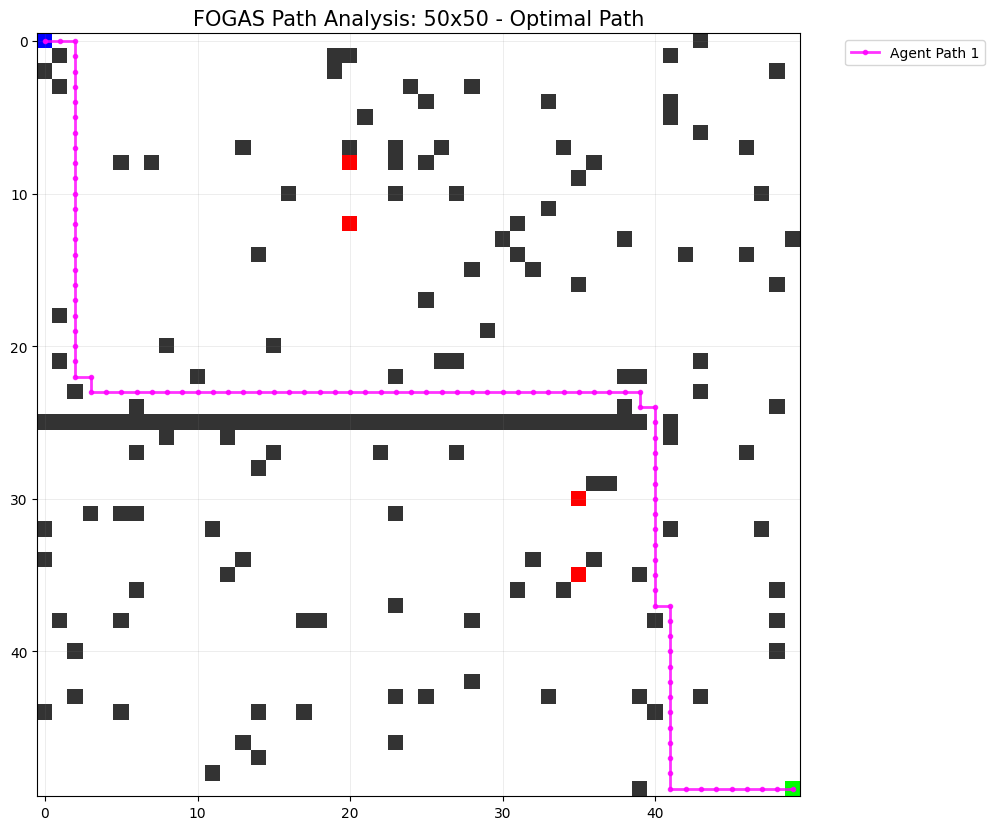

In [31]:
# --- STEP 1: Generate the Grid ---
# size = 50 or 100
size = 50 
grid_50 = create_fogas_grid(size)

# --- STEP 2: Generate MDP Components with Regular Grid ---
# We use 15 centers per side (225 total RBFs) for a 50x50 or 100x100 grid.
mdp_data = generate_mdp_regular_grid(grid_50, centers_per_side=15)

# --- STEP 3: Calculate Scale-Invariant Sigma ---
# Using Local KNN Sigma (k=2) ensures RBFs overlap with neighbors
# but don't become "blurry" across walls.
centers = mdp_data["centers"]
rbf_sigma = calculate_local_sigma(centers, k=2)

# --- STEP 4: Define the Scale-Invariant Phi Functions ---
# Note: size is passed here to ensure normalization: r / (size-1)
phi_s = get_phi_state_func(
    centers, 
    rbf_sigma, 
    size, 
    mdp_data["pits"], 
    mdp_data["goal"]
)

def phi(x, a):
    """Coupled Feature Map: phi(x, a) = e_a ⊗ phi_state(x)"""
    s_feat = phi_s(x)
    A = 4
    e_a = torch.zeros(A, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# Calculate Feature Dimension d
sample_feat = phi(0, 0)
d = int(sample_feat.shape[0])

# --- STEP 5: Create the FOGAS Solver Object ---
# (Assumes your PolicySolver class is defined as in your previous code)
states = torch.arange(size * size, dtype=torch.int64)
actions = torch.arange(4, dtype=torch.int64)

mdp = PolicySolver(
    states=states, 
    actions=actions, 
    phi=phi,
    reward_fn=mdp_data["reward_fn"], 
    gamma=mdp_data["gamma"], 
    x0=mdp_data["start"], 
    P=mdp_data["P"]
)
optimal_path = compute_optimal_path(mdp, mdp_data, size=50)
# 2. Plot the trajectory
plot_agent_paths(grid_50, [optimal_path], title_suffix="- Optimal Path")

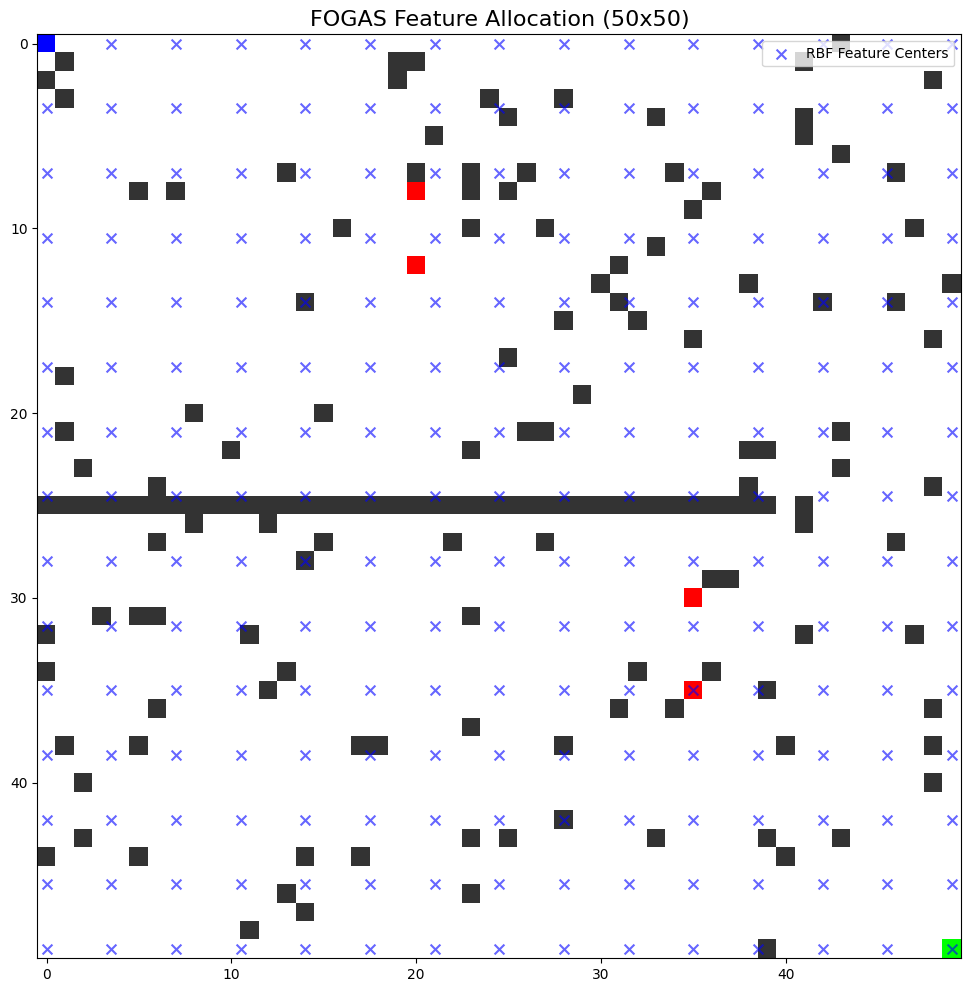

In [5]:
plot_grid_with_centers(grid_data=grid_50, centers=centers)

### Dataset creation

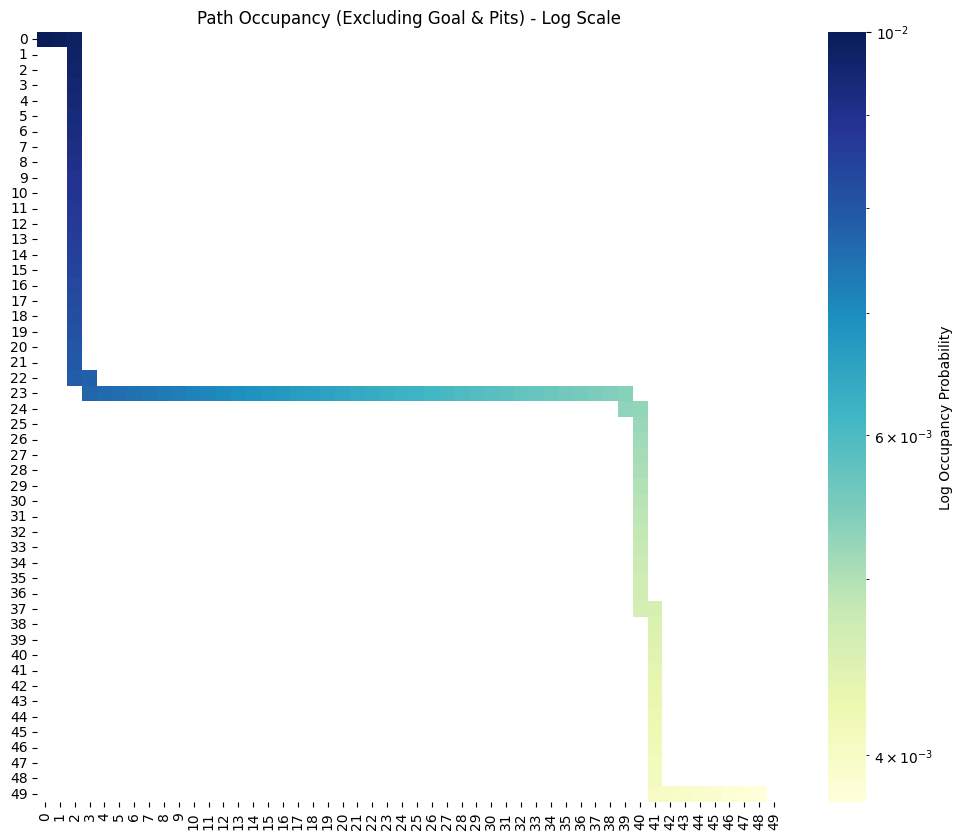

In [ ]:
# 1. Get occupancy probabilities
probs = mdp.state_mu_star.detach().cpu().numpy().copy()

# 2. Mask the Goal/Pits (Terminal States) for better visual scaling
# The goal index is usually size*size - 1
terminal_indices = list(mdp_data['pits']) + [mdp_data['goal']]
for idx in terminal_indices:
    probs[idx] = 0.0

# 3. Reshape
grid_size = 50
occupancy_grid = probs.reshape(grid_size, grid_size)

# 4. Plot with Log Normalization to see small probabilities along the path
plt.figure(figsize=(12, 10))
sns.heatmap(occupancy_grid, 
            cmap="YlGnBu", 
            norm=LogNorm(vmin=probs[probs>0].min() if any(probs>0) else 1e-6, vmax=probs.max()),
            cbar_kws={'label': 'Log Occupancy Probability'})

plt.title("Path Occupancy (Excluding Goal & Pits) - Log Scale")
plt.show()


In [67]:
reset_options = {
    'x0': 0.0, 
    'occupancy': 1.0
}

# Initialize the collector with these options
collector = EnvDataCollector(
    mdp=mdp,
    env_name="50grid",
    restricted_states=mdp_data["walls"],  # These will never be starting states
    reset_probs=reset_options,
    max_steps=200
)

# Create an epsilon-greedy pi_star (30% optimal, 70% random)
epsilon_policy = (mdp.pi_star, 0.3)

df = collector.collect_mixed_dataset_terminal_aware(
    policies=[epsilon_policy, "random"],  
    proportions=[0.8, 0.2],
    n_steps=60000,
    episode_based=True,                   
    save_path=str(DATASET_PATH),
    verbose=True,
    extra_steps=50 
)


  MIXED TERMINAL-AWARE DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 60000
Total episodes: 393
Extra steps: 50

Policy Distribution:
  Policy 0: 42827 steps (71.4%) | Target: 80.0% | Episodes: 306
  Policy 1: 17173 steps (28.6%) | Target: 20.0% | Episodes: 88

✅ Mixed terminal-aware dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/50grid.csv


In [76]:
analyzer = DatasetAnalyzer(DATASET_PATH)

ratio = analyzer.feature_coverage_ratio(
    mdp=mdp,
    beta=1e-7,
    use_optimal_policy=True,
    verbose=True,
    return_details=True,
)


Feature Coverage Ratio Details
------------------------------
  Dataset size (n):         60000
  MDP dims (N, A, d):        (2500, 4, 912)
  gamma:                    0.99
  beta (ridge):             1e-07
  policy source:            provided

  Occupancy μ_pi summary:
    sum:                    1
    min / max:              0 / 0.373464

  Feature occupancy λ_pi summary:
    ||λ||_2:                0.935865
    ||λ||_1:                6.09655
    max |λ_i|:              0.373464

  Empirical covariance Λ_n:
    diag min / mean / max:  1e-07 / 0.00439019 / 0.312783
    eig min / max:          1e-07 / 0.819065
    condition number:       8.19065e+06

  Coverage ratio:           3.19734


Total states: 2500
Walls: 161
Visited: 1228
Non-visited non-walls: 1111


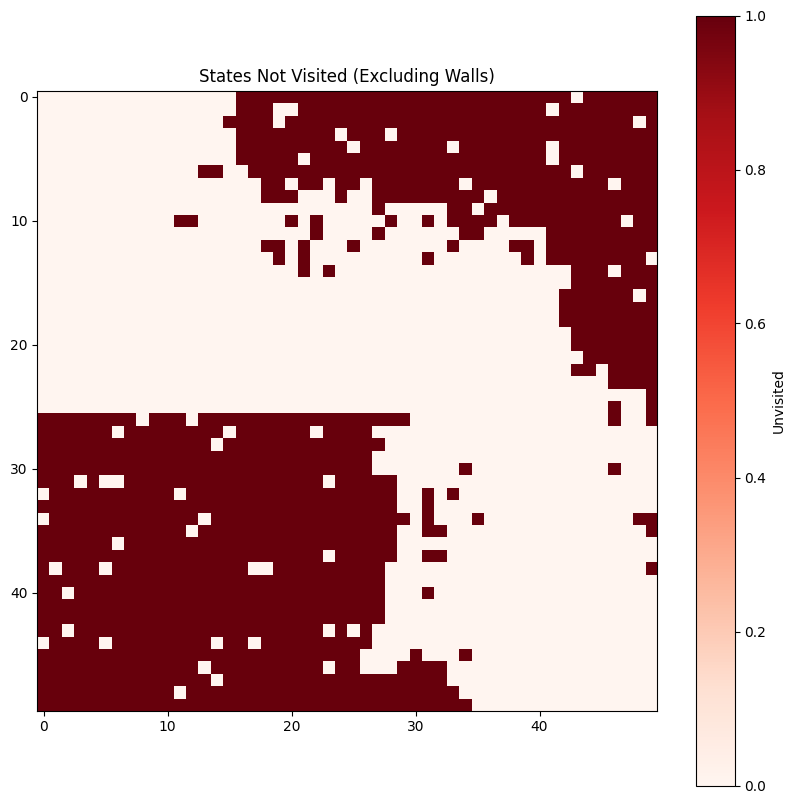

In [77]:
# 1. Get all visited states from your collected dataset
visited_states = set(df['state'].unique())

# 2. Get the set of wall states
# Since you are in the 50x50grid notebook, mdp_data contains the wall indices
wall_states = set(mdp_data['walls'])

# 3. Calculate states that were NOT visited and are NOT walls
all_states = set(range(mdp.N))
non_visited_non_walls = all_states - visited_states - wall_states

print(f"Total states: {mdp.N}")
print(f"Walls: {len(wall_states)}")
print(f"Visited: {len(visited_states)}")
print(f"Non-visited non-walls: {len(non_visited_non_walls)}")

# Optional: Convert indices to (row, col) coordinates for the 50x50 grid
size = 50
coords = [divmod(s, size) for s in sorted(list(non_visited_non_walls))]
# print(coords[:10]) # Show first 10 missing states

# Create an empty 50x50 map (0 = visited/wall, 1 = missing)
coverage_map = np.zeros((size, size))
for s in non_visited_non_walls:
    r, c = divmod(s, size)
    coverage_map[r, c] = 1
plt.figure(figsize=(10, 10))
plt.imshow(coverage_map, cmap='Reds')
plt.title("States Not Visited (Excluding Walls)")
plt.colorbar(label="Unvisited")
plt.show()


### Solving it

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-07, n=60000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
────────────────────────────────────────────
Max |error|                        0.013659
Mean |error|                       0.001440
RMSE                               0.002605
R² (explained variance)            0.999970


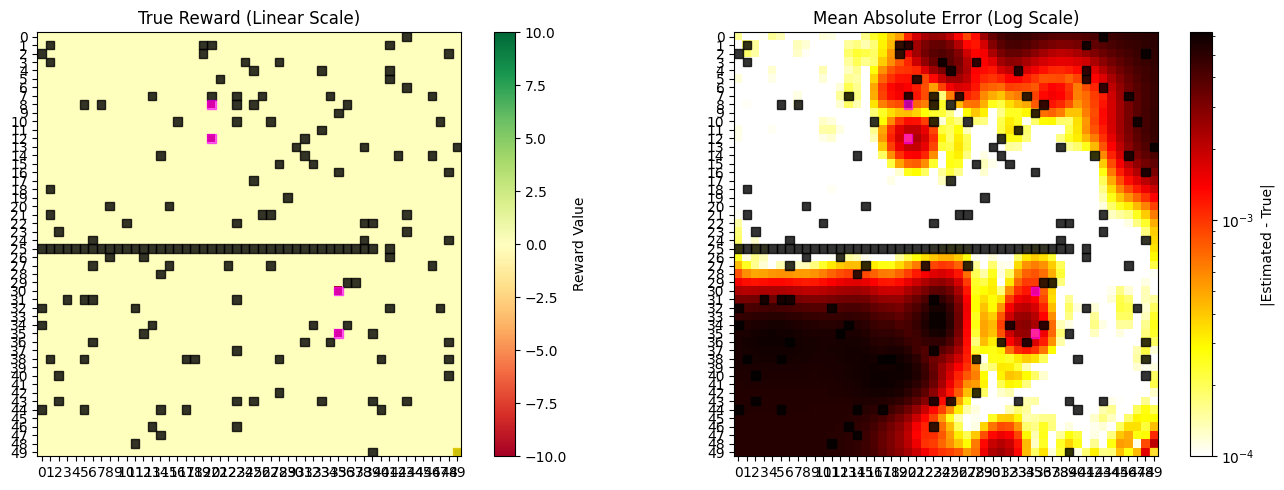

In [75]:
solver_e = FOGASSolverVectorized(
    mdp=mdp,
    csv_path=str(DATASET_PATH),
    device=device,
    beta=1e-7,
    seed=seed)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"), seed=seed)

evaluator_e.analyze_reward_approximation(
    walls=mdp_data["walls"], 
    pits=mdp_data["pits"], 
    goal=mdp_data["goal"]
)

In [65]:
# Run solver with best alpha and fixed rho, eta
solver_e.run(alpha=0.0001 / 2, eta=0.00002, rho=0.5, tqdm_print=True, T=30000)
evaluator_e.print_optimal_path(goal_state=2499)

FOGAS:   0%|                                                                                                                                     | 0/30000 [00:00<?, ?it/s]

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30000/30000 [02:53<00:00, 172.44it/s]



  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 2499
Discount Factor (γ): 0.99

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 0       │ Reward:  -0.010 │ → 0 ⚠️ SELF-LOOP
  Step   1 │ State: 0        │ Action: 0       │ Reward:  -0.010 │ → 0 ⚠️ SELF-LOOP
  Step   2 │ State: 0        │ Action: 0       │ Reward:  -0.010 │ → 0 ⚠️ SELF-LOOP
  Step   3 │ State: 0        │ Action: 0       │ Reward:  -0.010 │ → 0 ⚠️ SELF-LOOP
  Step   4 │ State: 0        │ Action: 0       │ Reward:  -0.010 │ → 0 ⚠️ SELF-LOOP
  Step   5 │ State: 0        │ Action: 0       │ Reward:  -0.010 │ → 0 ⚠️ SELF-LOOP
  Step   6 │ State: 0        │ Action: 0       │ Reward:  -0.010 │ → 0 ⚠️ SELF-LOOP
  Step   7 │ State: 0        │ Action: 0       │ Reward:  -0.010 │ → 0 ⚠️ SELF-LOOP
  Step   8 │ State: 0        │ Action: 0       │ Reward:  -0.010 │ → 0 ⚠️ SELF-LOOP
  Step   9 │ State: 0        │ Action: 0       │ Rewa

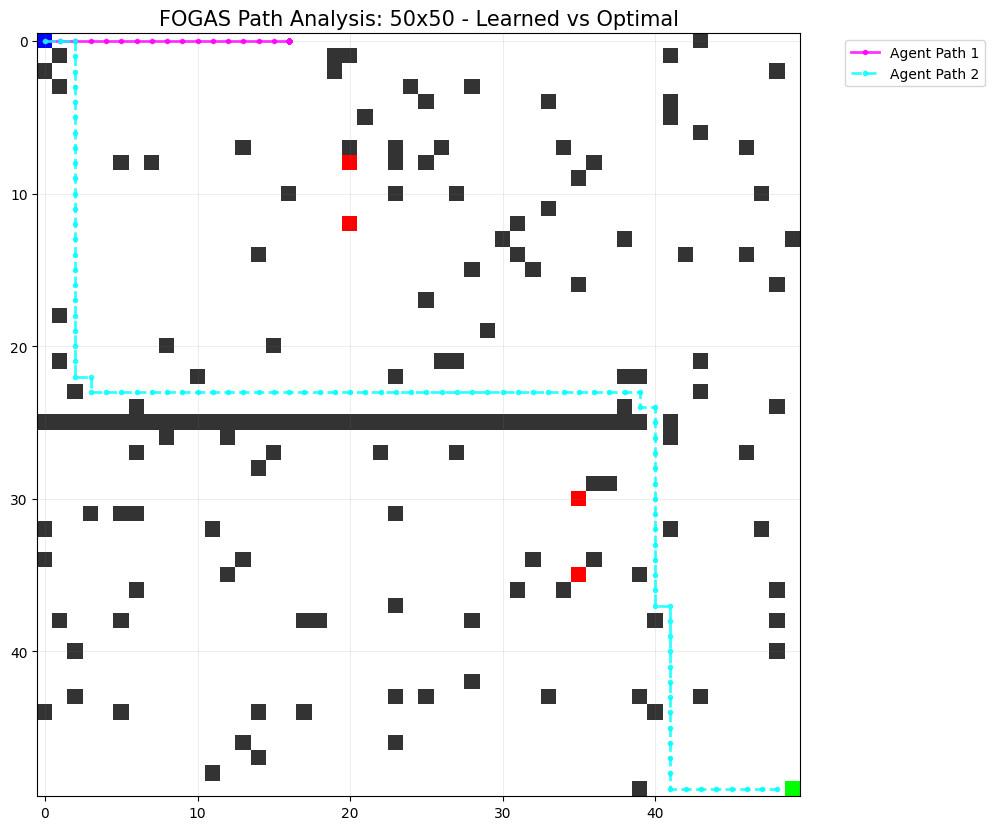

In [61]:
traj = evaluator_e.simulate_trajectory(goal_state=2499)
# 2. Extract the state indices and convert them to (row, col) coordinates
size = 50 # Or your grid_data.shape[0]
path_coords = [divmod(step['state'], size) for step in traj]
# Simulate the optimal policy trajectory
traj_opt = evaluator_e.simulate_trajectory(pi=evaluator_e.mdp.pi_star, goal_state=2499)
path_opt = [divmod(step['state'], size) for step in traj_opt]

# Plot both to see how close your learned policy is to optimal
plot_agent_paths(grid_50, [path_coords, path_opt], title_suffix="- Learned vs Optimal")

In [ ]:
evaluator_e.print_optimal_path(goal_state=999)


  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 999
Discount Factor (γ): 0.99

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 3       │ Reward:  -0.010 │ → 1
  Step   1 │ State: 1        │ Action: 3       │ Reward:  -0.010 │ → 2
  Step   2 │ State: 2        │ Action: 3       │ Reward:  -0.010 │ → 3
  Step   3 │ State: 3        │ Action: 3       │ Reward:  -0.010 │ → 4
  Step   4 │ State: 4        │ Action: 3       │ Reward:  -0.010 │ → 5
  Step   5 │ State: 5        │ Action: 3       │ Reward:  -0.010 │ → 6
  Step   6 │ State: 6        │ Action: 3       │ Reward:  -0.010 │ → 7
  Step   7 │ State: 7        │ Action: 3       │ Reward:  -0.010 │ → 8
  Step   8 │ State: 8        │ Action: 3       │ Reward:  -0.010 │ → 9
  Step   9 │ State: 9        │ Action: 3       │ Reward:  -0.010 │ → 10
  Step  10 │ State: 10       │ Action: 3       │ Reward:  -0.010 │ → 11
  Step  11 │ State: 11     

## 100 grid

In [ ]:
# --- STEP 1: Generate the Grid ---
# Create base 50x50 and scale to 100x100
size_50 = 50 
grid_50 = create_fogas_grid(size_50)
grid_100 = scale_grid(grid_50, factor=2)
size_100 = grid_100.shape[0] # This will be 100

# --- STEP 2: Generate MDP Components with Regular Grid ---
# We generate the transition matrix and MDP data for the 100x100 grid.
mdp1_data = generate_mdp_regular_grid(grid_100, centers_per_side=15)

# --- STEP 3: Calculate Scale-Invariant Sigma ---
centers = mdp1_data["centers"]
rbf_sigma = calculate_local_sigma(centers, k=2)

# --- STEP 4: Define the Scale-Invariant Phi Functions ---
# CRITICAL: Pass size_100 here so coordinate normalization is r / (100-1)
phi_s = get_phi_state_func(
    centers, 
    rbf_sigma, 
    size_100, 
    mdp1_data["pits"], 
    mdp1_data["goal"]
)

def phi(x, a):
    """Coupled Feature Map: phi(x, a) = e_a ⊗ phi_state(x)"""
    s_feat = phi_s(x)
    A = 4
    e_a = torch.zeros(A, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# Calculate Feature Dimension d for the solver
sample_feat = phi(0, 0)
d = int(sample_feat.shape[0])

# --- STEP 5: Create the FOGAS Solver Object ---
# Ensure states matches the 100x100 count (10,000)
states_100 = torch.arange(size_100 * size_100, dtype=torch.int64)
actions = torch.arange(4, dtype=torch.int64)

mdp1 = PolicySolver(
    states=states_100, 
    actions=actions, 
    phi=phi,
    reward_fn=mdp1_data["reward_fn"], # Updated to use 100x100 reward
    gamma=mdp1_data["gamma"], 
    x0=mdp1_data["start"],           # Updated to use 100x100 start index
    P=mdp1_data["P"]                 # Updated to use 100x100 transition matrix
)

# --- STEP 6: Compute and Plot Path ---
# compute_optimal_path uses the solver's pi_star and mdp1_data's P matrix
optimal_path = compute_optimal_path(mdp1, mdp1_data, size=size_100)

# Plot the trajectory on the 100x100 grid
plot_agent_paths(grid_100, [optimal_path], title_suffix="- Optimal Path (Scale 100x100)")

In [ ]:
plot_grid_with_centers(grid_data=grid_50, centers=centers)

### Dataset collection

In [ ]:
# 1. Get occupancy probabilities for the 100x100 MDP
probs1 = mdp1.state_mu_star.detach().cpu().numpy().copy()

# 2. Mask the Goal/Pits (Terminal States) for better visual scaling
# Uses the mdp1_data containing indices for the 100x100 grid
terminal_indices1 = list(mdp1_data['pits']) + [mdp1_data['goal']]
for idx in terminal_indices1:
    probs1[idx] = 0.0

# 3. Reshape using the new grid size
grid_size1 = 100
occupancy_grid1 = probs1.reshape(grid_size1, grid_size1)

# 4. Plot with Log Normalization
plt.figure(figsize=(12, 10))
sns.heatmap(
    occupancy_grid1, 
    cmap="YlGnBu", 
    norm=LogNorm(
        vmin=probs1[probs1 > 0].min() if any(probs1 > 0) else 1e-6, 
        vmax=probs1.max()
    ),
    cbar_kws={'label': 'Log Occupancy Probability'}
)

plt.title(f"Path Occupancy (Excluding Goal & Pits) - Log Scale {grid_size1}x{grid_size1}")
plt.show()


In [ ]:
reset_options1 = {
    'x0': 0.0, 
    'occupancy': 1.0
}

# Initialize the collector for the 100x100 grid
collector1 = EnvDataCollector(
    mdp=mdp1,
    env_name="100grid",                   # Updated name
    restricted_states=mdp1_data["walls"], # Using 100x100 wall indices
    reset_probs=reset_options1,
    max_steps=400                         # Increased for 100x100 distance
)

# Create an epsilon_greedy pi_star for the 100x100 policy
epsilon_policy1 = (mdp1.pi_star, 0.3)

df1 = collector1.collect_mixed_dataset_terminal_aware(
    policies=[epsilon_policy1, "random"],  
    proportions=[0.8, 0.2],
    n_steps=60000, 
    episode_based=True,                   
    save_path=str(DATASET_PATH1),
    verbose=True,
    extra_steps=50 
)


In [ ]:
# 1. Get all visited states from your collected 100x100 dataset
visited_states1 = set(df1['state'].unique())

# 2. Get the set of wall states for the 100x100 grid
wall_states1 = set(mdp1_data['walls'])

# 3. Calculate states that were NOT visited and are NOT walls
all_states1 = set(range(mdp1.N))
non_visited_non_walls1 = all_states1 - visited_states1 - wall_states1

print(f"Total states (100x100): {mdp1.N}")
print(f"Walls: {len(wall_states1)}")
print(f"Visited: {len(visited_states1)}")
print(f"Non-visited non-walls: {len(non_visited_non_walls1)}")

# Convert indices to (row, col) coordinates for the 100x100 grid
size1 = 100
coords1 = [divmod(s, size1) for s in sorted(list(non_visited_non_walls1))]

# Create an empty 100x100 map (0 = visited/wall, 1 = missing)
coverage_map1 = np.zeros((size1, size1))
for s in non_visited_non_walls1:
    r, c = divmod(s, size1)
    coverage_map1[r, c] = 1

plt.figure(figsize=(10, 10))
plt.imshow(coverage_map1, cmap='Reds')
plt.title(f"100x100 States Not Visited (Excluding Walls)")
plt.colorbar(label="Unvisited")
plt.show()

### Solving it

[FOGASSolverVectorized] omega estimated via regression (beta_omega=8.04e-07, n=8000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
────────────────────────────────────────────
Max |error|                        5.233793
Mean |error|                       0.130783
RMSE                               0.524553
R² (explained variance)            0.762358

--------------------------------------------------
State  Action         r_true      r_hat      error
──────────────────────────────────────────────────
0            ↑ Up          -0.1000    -0.1014    -0.0014
0            ↓ Down        -0.1000    -0.1024    -0.0024
0            ← Left        -0.1000    -0.1013    -0.0013
0            → Right       -0.1000    -0.1004    -0.0004
1            ↑ Up          -0.1000    -0.1007    -0.0007
1            ↓ Down        -0.1000    -0.0997     0.0003
1            ← Left        -0.1000    -0.0998     0.0002
1            → Right       -0.1000    -0.0998     0.0002
2   

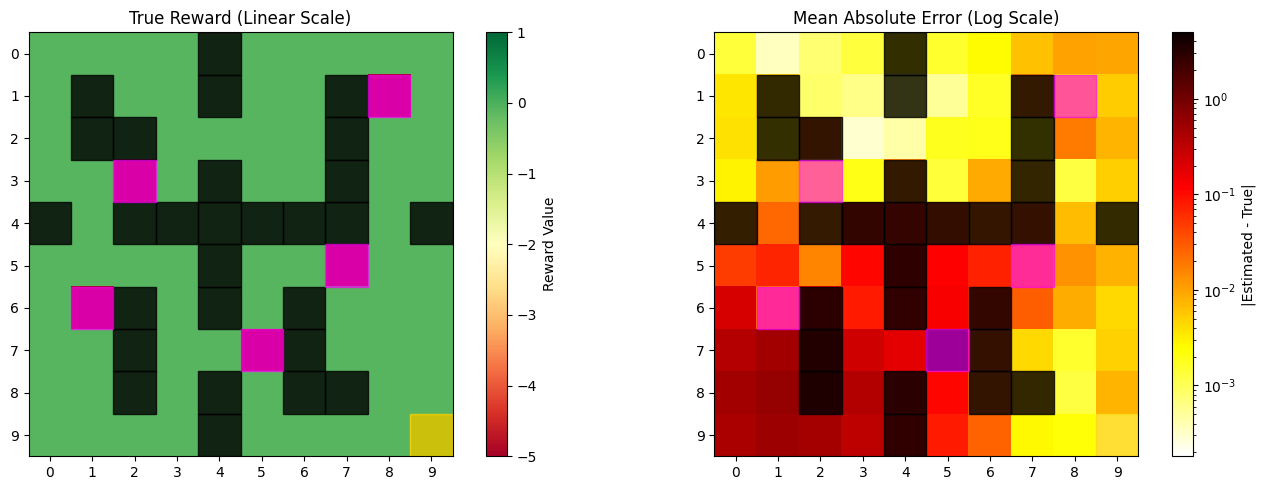

In [ ]:
# Initialize the vectorized solver for the 100x100 dataset
solver1_e = FOGASSolverVectorized(
    mdp=mdp1,
    csv_path=str(DATASET_PATH1),
    device=device,
    beta=1e-7,
    seed=seed
)

# Initialize the evaluator for the 100x100 solver
evaluator1_e = FOGASEvaluator(solver1_e)

# Initialize the hyperparameter optimizer for 100x100
optimizer1_e = FOGASHyperOptimizer(
    solver=solver1_e,
    metric_callable=evaluator1_e.get_metric("reward"), 
    seed=seed
)

# Run the reward approximation analysis on the 100x100 environment
evaluator1_e.analyze_reward_approximation(
    walls=mdp1_data["walls"], 
    pits=mdp1_data["pits"], 
    goal=mdp1_data["goal"]
)


In [ ]:
# Run the 100x100 solver with your specific alpha, eta, and rho
# Note: For 100x100, you might eventually need a higher T, but kept as 13000 per your code
solver1_e.run(
    alpha=0.001 / 2, 
    eta=0.0002, 
    rho=0.05, 
    tqdm_print=True, 
    T=13000
)

# Print the optimal path reaching the 100x100 goal (State 9999)
evaluator1_e.print_optimal_path(goal_state=mdp1_data["goal"])


FOGAS:   0%|                                                                                                                                                   | 0/13000 [00:00<?, ?it/s]

FOGAS: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13000/13000 [00:07<00:00, 1712.32it/s]


  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 99
Discount Factor (γ): 0.9

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 3       │ Reward:  -0.100 │ → 1
  Step   1 │ State: 1        │ Action: 3       │ Reward:  -0.100 │ → 2
  Step   2 │ State: 2        │ Action: 1       │ Reward:  -0.100 │ → 12
  Step   3 │ State: 12       │ Action: 3       │ Reward:  -0.100 │ → 13
  Step   4 │ State: 13       │ Action: 1       │ Reward:  -0.100 │ → 23
  Step   5 │ State: 23       │ Action: 3       │ Reward:  -0.100 │ → 24
  Step   6 │ State: 24       │ Action: 3       │ Reward:  -0.100 │ → 25
  Step   7 │ State: 25       │ Action: 0       │ Reward:  -0.100 │ → 15
  Step   8 │ State: 15       │ Action: 3       │ Reward:  -0.100 │ → 16
  Step   9 │ State: 16       │ Action: 0       │ Reward:  -0.100 │ → 6
  Step  10 │ State: 6        │ Action: 3       │ Reward:  -0.100 │ → 7
  Step  11 │ State: 7   